# Day 2 - Lab 2: Visualisation with Matplotlib and Seaborn

**Goal:** turn the numbers from Lab 1 into pictures a manager can read in five seconds. Matplotlib for control, Seaborn for speed. End with one chart you would put in front of a director.

A picture is not decoration. The right chart *is* the analysis: it shows the shape a table hides.

## 1. Load

In [1]:
import pandas as pd, numpy as np
from pathlib import Path

def find_data(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'data').is_dir():
            return p / 'data'
    raise FileNotFoundError('data/ folder not found')

DATA = find_data()

def _rebuild_clean():
    """Re-run the Day 1 cleaning from raw, so Day 2 is self-contained."""
    df = pd.read_csv(DATA / 'raw' / 'service_requests_raw.csv', dtype=str).drop_duplicates()
    df['priority'] = df['priority'].str.strip().str.title().replace({'2': 'Medium'})
    df['resolution_hours'] = pd.to_numeric(df['resolution_hours'], errors='coerce')
    iso   = pd.to_datetime(df['submitted_at'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    named = pd.to_datetime(df['submitted_at'], format='%d-%b-%Y %H:%M', errors='coerce')
    df['submitted_at'] = iso.fillna(named)
    df['resolved_at'] = pd.to_datetime(df['resolved_at'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    df.loc[(df['resolution_hours'] < 0) | (df['resolution_hours'] > 8760), 'resolution_hours'] = np.nan
    df.loc[(df['resolved_at'] < df['submitted_at']).fillna(False), 'resolved_at'] = pd.NaT
    df['citizen_age_band'] = df['citizen_age_band'].replace({'': pd.NA, 'Unknown': pd.NA}).fillna('Unknown')
    df['service_id'] = pd.to_numeric(df['service_id'], errors='coerce')
    svc = pd.read_csv(DATA / 'seeds' / 'services.csv')
    df = df.merge(svc[['service_id', 'target_resolution_hours']], on='service_id', how='left')
    resolved = df['status'].isin(['Resolved', 'Reopened']) & df['resolution_hours'].notna()
    df['sla_met'] = pd.NA
    df.loc[resolved, 'sla_met'] = (df.loc[resolved, 'resolution_hours'] <= df.loc[resolved, 'target_resolution_hours']).astype('int')
    return df

def load_clean():
    p = DATA / 'processed' / 'service_requests_clean.csv'
    if p.exists():
        print('Loaded cleaned dataset from Day 1:', p.name)
        return pd.read_csv(p, parse_dates=['submitted_at', 'resolved_at'])
    print('Cleaned file not found, rebuilding from raw (Day 1 cleaning)...')
    return _rebuild_clean()

df = load_clean()
channels = pd.read_csv(DATA / 'seeds' / 'channels.csv')
districts = pd.read_csv(DATA / 'seeds' / 'districts.csv')
df = df.merge(channels, on='channel_id', how='left')
print('shape:', df.shape)
df.head(3)

Loaded cleaned dataset from Day 1: service_requests_clean.csv
shape: (12027, 16)


,request_id,submitted_at,service_id,channel_id,district_id,department_id,priority,status,resolved_at,resolution_hours,satisfaction_score,citizen_age_band,target_resolution_hours,sla_met,channel_name,is_digital
0,1003304,2024-07-13 06:38:00,13,1,101,2,Low,Open,NaT,99.2,NaN,35-44,72,NaN,Web Portal,True
1,1011864,2024-05-22 13:06:00,19,2,100,5,High,Resolved,2024-05-24 09:36:00,44.5,NaN,25-34,96,1.0,Mobile App,True
2,1001507,2024-02-13 01:07:00,10,1,104,1,Low,Resolved,2024-02-13 16:43:00,15.6,NaN,25-34,24,1.0,Web Portal,True


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')   # sensible defaults for the whole notebook

## 2. Matplotlib fundamentals: figure and axes
Every Matplotlib chart is a **figure** (the canvas) holding one or more **axes** (the plot). Create them explicitly with `plt.subplots()`; it is the habit that scales to multi-panel figures.

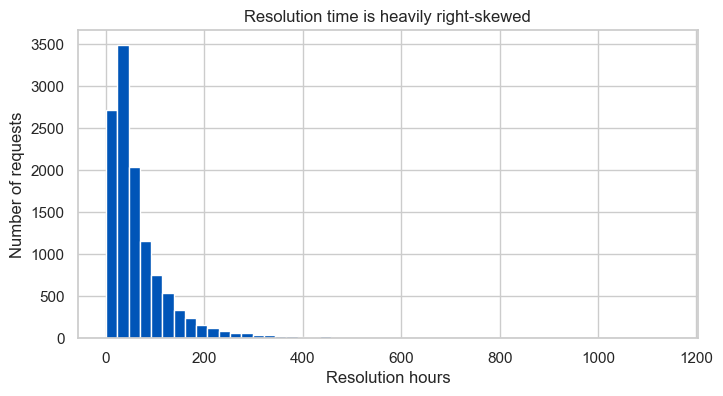

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['resolution_hours'].dropna(), bins=50, color='#0055B8')
ax.set_title('Resolution time is heavily right-skewed')
ax.set_xlabel('Resolution hours')
ax.set_ylabel('Number of requests')
plt.show()

The long tail you measured as skew in Lab 1 is now obvious: most requests cluster low, a few stretch far right.

## 3. Seaborn: the same idea, less code
Seaborn sits on top of Matplotlib and knows about DataFrames. A distribution with a smooth density curve is one line.

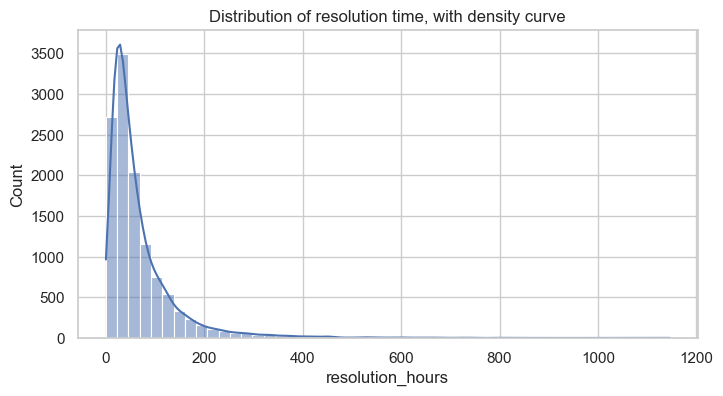

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x='resolution_hours', bins=50, kde=True, ax=ax)
ax.set_title('Distribution of resolution time, with density curve')
plt.show()

## 4. Compare groups: box and violin plots
A box plot shows median, IQR and outliers per group. Order the boxes by median so the story reads left to right.

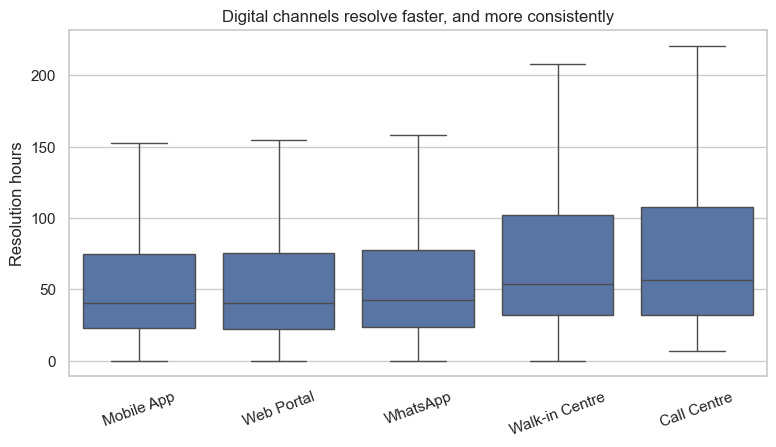

In [5]:
order = df.groupby('channel_name')['resolution_hours'].median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x='channel_name', y='resolution_hours', order=order, showfliers=False, ax=ax)
ax.set_title('Digital channels resolve faster, and more consistently')
ax.set_xlabel(''); ax.set_ylabel('Resolution hours')
plt.xticks(rotation=20)
plt.show()

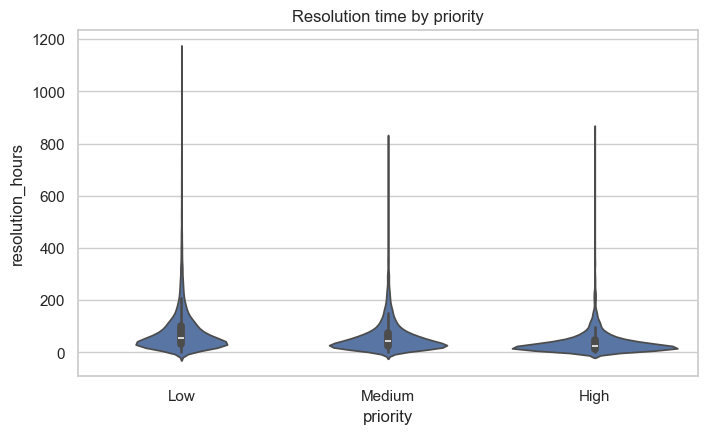

In [6]:
# A violin plot adds the shape of each distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(data=df, x='priority', y='resolution_hours', order=['Low','Medium','High'], ax=ax)
ax.set_title('Resolution time by priority')
plt.show()

## 5. Categorical counts

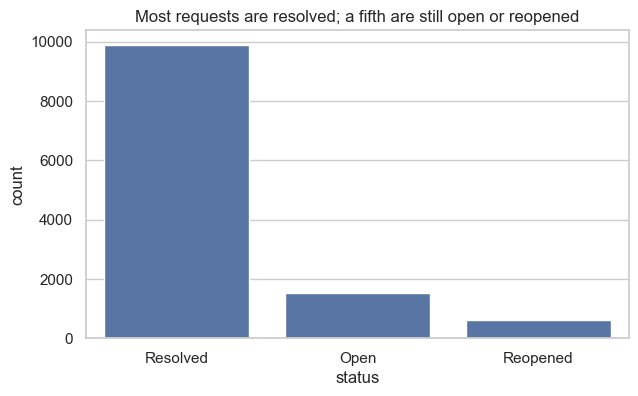

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='status', order=df['status'].value_counts().index, ax=ax)
ax.set_title('Most requests are resolved; a fifth are still open or reopened')
plt.show()

## 6. Correlation heatmap
A heatmap reads a correlation matrix at a glance. Strong red or blue off the diagonal is what you scan for.

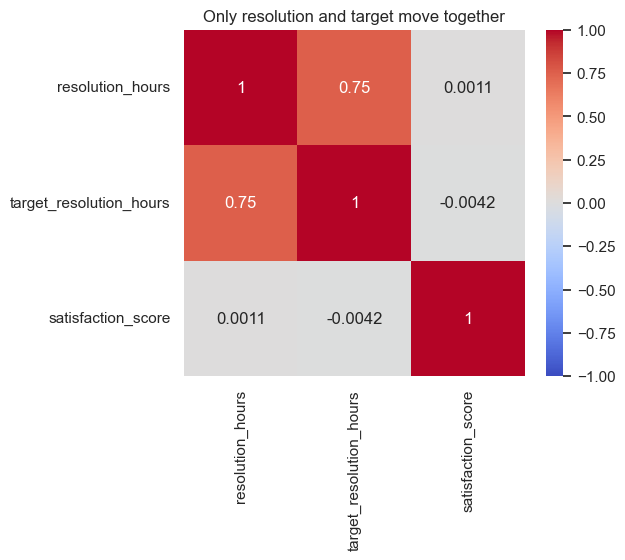

In [8]:
num = df[['resolution_hours', 'target_resolution_hours', 'satisfaction_score']]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(num.corr(), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Only resolution and target move together')
plt.show()

Resolution time tracks the target (0.75), as expected. Satisfaction moves with neither (about 0.00), a real finding: on this data it is not explained by speed.

## 7. A trend over time
Volume by month tells operations whether demand is growing.

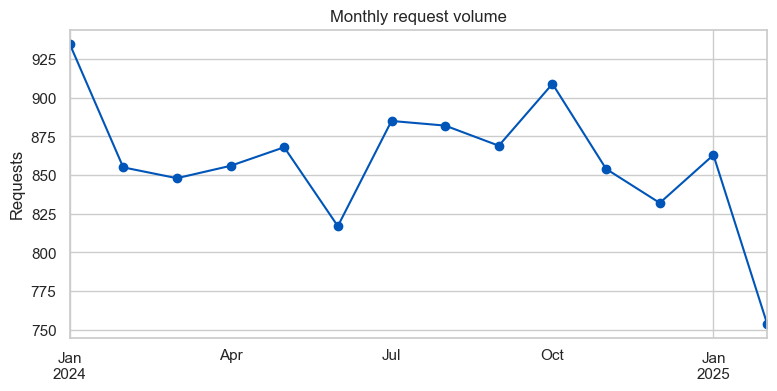

In [9]:
monthly = df.set_index('submitted_at').resample('MS').size()
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker='o', color='#0055B8')
ax.set_title('Monthly request volume')
ax.set_xlabel(''); ax.set_ylabel('Requests')
plt.show()

## 8. One chart for the director
Now compose deliberately: a single, annotated comparison that makes the digital-channel finding undeniable. Colour, title and annotation all pull one way.

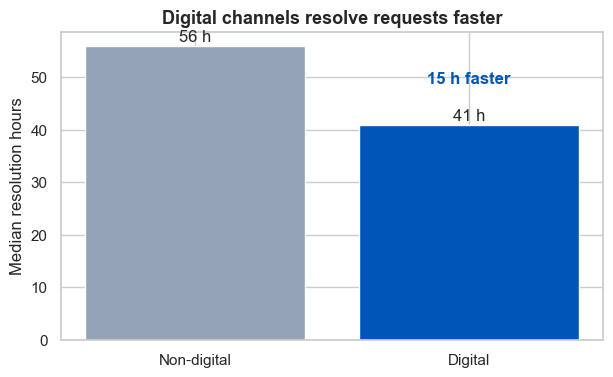

In [10]:
summary = (df.groupby('is_digital')['resolution_hours'].median()
             .rename(index={True: 'Digital', False: 'Non-digital'}))
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(summary.index, summary.values, color=['#94A3B8', '#0055B8'])
ax.set_title('Digital channels resolve requests faster', fontsize=13, weight='bold')
ax.set_ylabel('Median resolution hours')
gap = summary['Non-digital'] - summary['Digital']
ax.annotate(f'{gap:.0f} h faster', xy=(1, summary['Digital']), xytext=(1, summary['Digital'] + 8),
            ha='center', color='#0055B8', weight='bold')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{b.get_height():.0f} h', ha='center')
plt.show()

## Your turn
1. Draw a box plot of `resolution_hours` by `priority`. Does the spread differ as much as the centre?
2. Plot SLA-met rate by channel as a bar chart (hint: `groupby(...)['sla_met'].mean()`).
3. Take any chart above and improve it for a non-technical audience: title that states the finding, clear axis labels, no clutter.

In [11]:
# your turn